In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report , confusion_matrix , accuracy_score
from sklearn.model_selection import train_test_split

from PIL import Image 
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Input, Dense,Conv2D , MaxPooling2D, Flatten,BatchNormalization,Dropout
from tensorflow.keras.preprocessing import image


In [2]:
normal_path ="C:/Users/StarNet/Downloads/graduation project/Stroke data MRI/Brain_Data_Organised/Normal"
stroke_path ="C:/Users/StarNet/Downloads/graduation project/Stroke data MRI/Brain_Data_Organised/Stroke"

In [3]:
normal_folder = os.listdir(normal_path)
stroke_folder = os.listdir(stroke_path)

In [4]:
print("Images in Normal Data:",len(normal_folder))
print("Images in Stroke Data:",len(stroke_folder))

Images in Normal Data: 1551
Images in Stroke Data: 1352


In [6]:
data = []

for img_file in normal_folder:
    imag = Image.open("C:/Users/StarNet/Downloads/graduation project/Stroke data MRI/Brain_Data_Organised/Normal/" + img_file)
    imag = imag.resize((224,224))
    imag = imag.convert('RGB')
    imag = np.array(imag)
    data.append(imag)
    
for img_file in stroke_folder:
    imag = Image.open("C:/Users/StarNet/Downloads/graduation project/Stroke data MRI/Brain_Data_Organised/Stroke/" + img_file)
    imag = imag.resize((224,224))
    imag = imag.convert('RGB')
    imag = np.array(imag)
    data.append(imag)

In [7]:
len(data)


2903

In [8]:
normal_label = [0]*len(normal_folder)
stroke_label = [1]*len(stroke_folder)

In [9]:
Target_label = normal_label + stroke_label

In [10]:
len(Target_label)

2903

In [11]:
x = np.array(data)
y = np.array(Target_label)

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,shuffle=True)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(2322, 224, 224, 3)
(581, 224, 224, 3)
(2322,)
(581,)


In [13]:
x_train_s = x_train/255
x_test_s = x_test/255

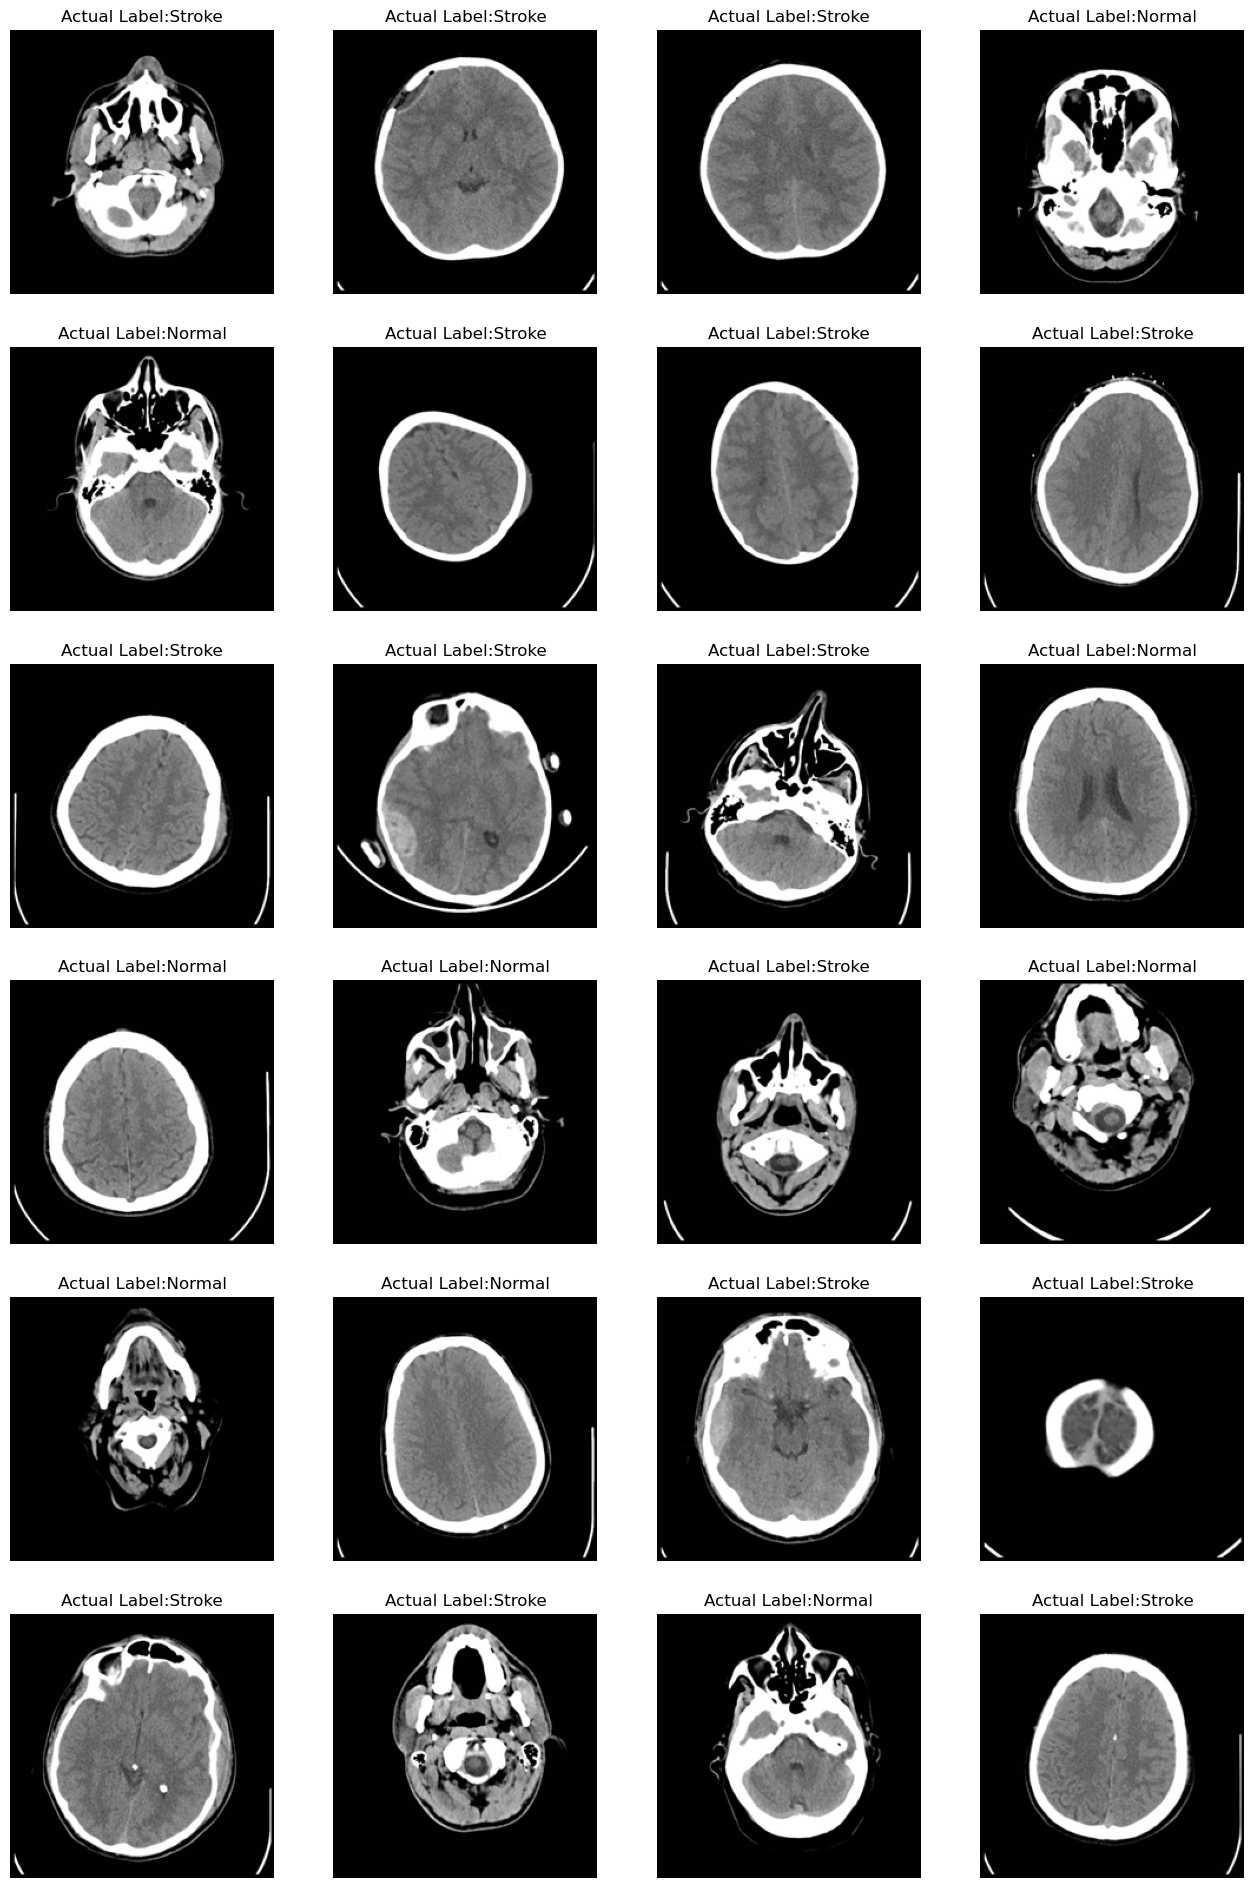

In [14]:
class_labels = ["Normal","Stroke"]
plt.figure(figsize=(16,24))
for i in range(24):
    plt.subplot(6,4,i+1)
    plt.imshow(x_train[i])
    plt.title(f"Actual Label:{class_labels[y_train[i]]}")
    plt.axis("off")

In [39]:
model = Sequential()

model.add(Conv2D(filters=100,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu", input_shape=(224,224,3)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=80,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64,kernel_size=(3,3),strides=(1,1),padding="valid",activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(units=500, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(units=500, activation="relu"))
model.add(Dropout(0.2))
model.add(Dense(units=1, activation="sigmoid"))

model.compile(optimizer="adam",loss="binary_crossentropy",
             metrics=["accuracy"])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 100)  │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 100)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 80)   │        72,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 80)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 64)     │        46,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 43264)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 500)            │    21,632,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 500)            │       250,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,004,525 (83.94 MB)

 Trainable params: 22,004,525 (83.94 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
history = model.fit(x_train_s,y_train,batch_size=32,
         epochs=5, validation_data=(x_test_s,y_test))

Epoch 1/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 107s 1s/step - accuracy: 0.5793 - loss: 0.8038 - val_accuracy: 0.8330 - val_loss: 0.3665
Epoch 2/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 60s 812ms/step - accuracy: 0.8872 - loss: 0.2554 - val_accuracy: 0.9466 - val_loss: 0.1420
Epoch 3/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 58s 788ms/step - accuracy: 0.9627 - loss: 0.0918 - val_accuracy: 0.9604 - val_loss: 0.0937
Epoch 4/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.9769 - loss: 0.0454 - val_accuracy: 0.8967 - val_loss: 0.2554
Epoch 5/5
73/73 ━━━━━━━━━━━━━━━━━━━━ 57s 776ms/step - accuracy: 0.9749 - loss: 0.0850 - val_accuracy: 0.9501 - val_loss: 0.0990


In [41]:
loss, acc = model.evaluate(x_test_s,y_test)
print("Loss on Test Data:",loss)
print("Accuracy on Test Data:",acc)
print()

loss, acc = model.evaluate(x_train_s,y_train)
print("Loss on Train Data:",loss)
print("Accuracy on Train Data:",acc)

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 176ms/step - accuracy: 0.9617 - loss: 0.0785
Loss on Test Data: 0.09902674704790115
Accuracy on Test Data: 0.9500860571861267

73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 172ms/step - accuracy: 0.9886 - loss: 0.0303
Loss on Train Data: 0.0292461309581995
Accuracy on Train Data: 0.9888027310371399


In [42]:
ypred=model.predict(x_test)
y_pred_test_label = [1 if i>=0.5 else 0 for i in ypred]
y_pred_test_label

print(classification_report(y_test,y_pred_test_label))

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 169ms/step
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       317
           1       0.96      0.94      0.95       264

    accuracy                           0.95       581
   macro avg       0.95      0.95      0.95       581
weighted avg       0.95      0.95      0.95       581



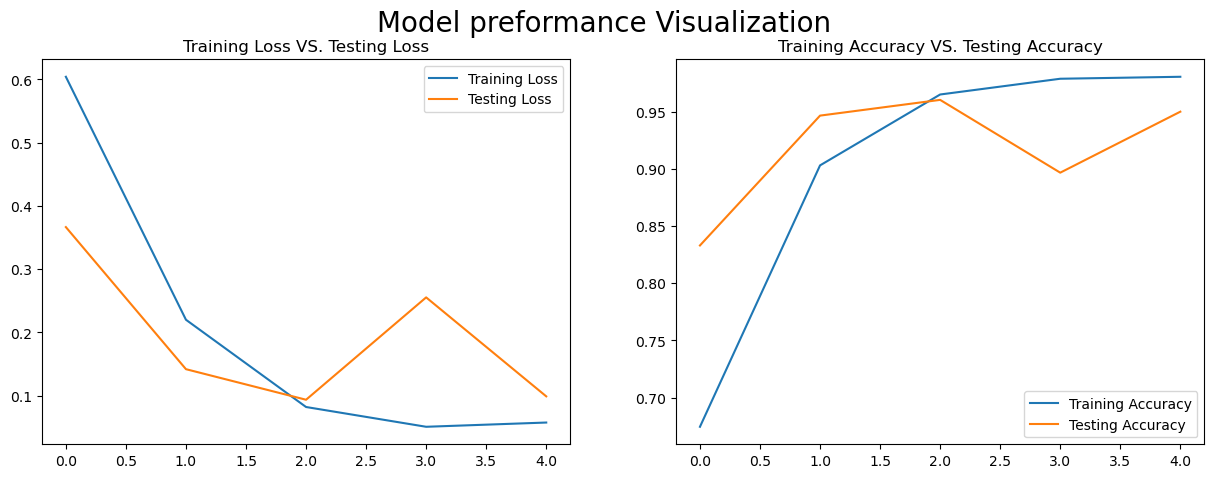

In [43]:
fig,ax=plt.subplots(1,2,figsize=(15,5))
fig.suptitle("Model preformance Visualization",fontsize=20)
ax[0].plot(history.history['loss'],label='Training Loss')
ax[0].plot(history.history['val_loss'],label='Testing Loss')
ax[0].set_title("Training Loss VS. Testing Loss")
ax[0].legend()

ax[1].plot(history.history['accuracy'],label='Training Accuracy')
ax[1].plot(history.history['val_accuracy'],label='Testing Accuracy')
ax[1].set_title("Training Accuracy VS. Testing Accuracy")
ax[1].legend()

plt.show()

In [27]:
classes = ['Normal', 'Stroke']

class_map = {index: class_name for index, class_name in enumerate(classes)}

In [28]:
class_map

{0: 'Normal', 1: 'Stroke'}

In [46]:
def pred(actual_label,test_img):
    img=image.load_img(test_img,target_size=(224,224))
    img_array=image.img_to_array(img)/255
    img_reshape=np.reshape(img_array,(1,img_array.shape[0],
                                      img_array.shape[1],
                                      img_array.shape[2]))
    

    pred=model.predict(img_reshape)
    pred_label=[1 if i >=0.5 else 0 for i in pred][0]
    class_label=class_map[pred_label]

    plt.figure(figsize=(10,5))
    plt.imshow(img_array)
    plt.grid()
    plt.axis('off')
    plt.title(f"Actual Label is: {actual_label} | predict label is: {class_label}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


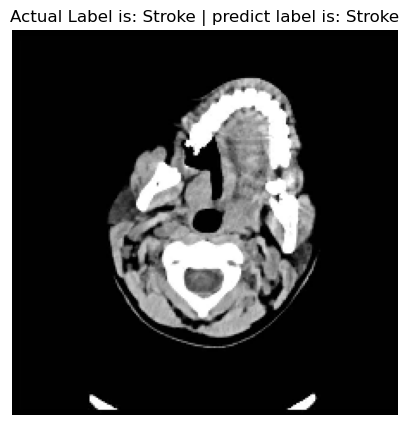

In [47]:
pred('Stroke',"C:/Users/StarNet/Downloads/graduation project/Stroke data MRI/Brain_Data_Organised/Stroke/stroke (246).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


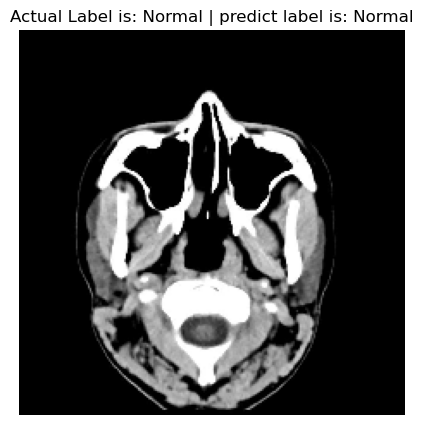

In [48]:
pred('Normal','D:/n.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


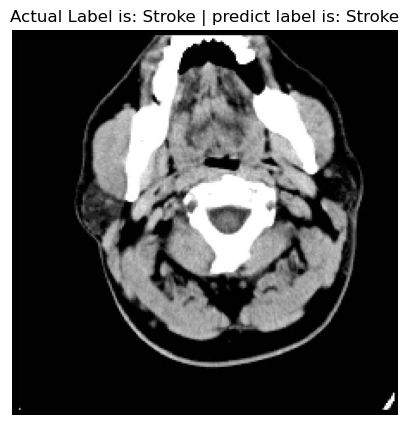

In [49]:
pred('Stroke',"D:/stroke-test.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


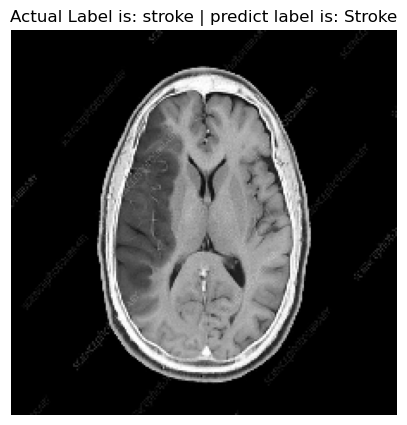

In [50]:
pred('stroke',"D:/stroke image.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


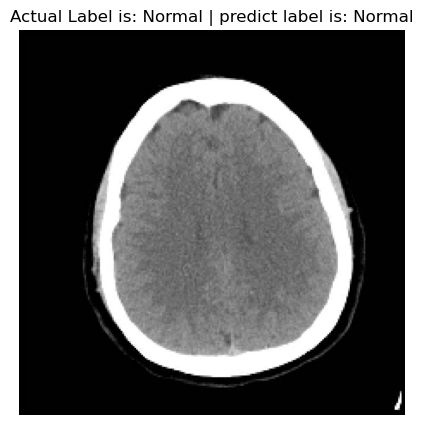

In [51]:
pred('Normal',"C:/Users/StarNet/Downloads/graduation project/Stroke-MRI/Brain_Stroke_CT-SCAN_image/Test/Normal/98 (19).jpg")

In [52]:
model.save("C:/Users/StarNet/Downloads/graduation project.h5")